In [114]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import linregress

In [11]:
with open("/Users/compneuro1/Documents/projects/SOC/static_N100.pkl", 'rb') as f:
    N100 = pickle.load(f)

In [15]:
with open("/Users/compneuro1/Documents/projects/SOC/static.pkl", 'rb') as f:
    N200 = pickle.load(f)

In [124]:
with open("/Users/compneuro1/Documents/projects/SOC/test.pkl", 'rb') as f:
    test = pickle.load(f)

In [125]:
test.keys()

dict_keys(['lamb', 'connectivity', 'fire_data', 'initial_connectivity'])

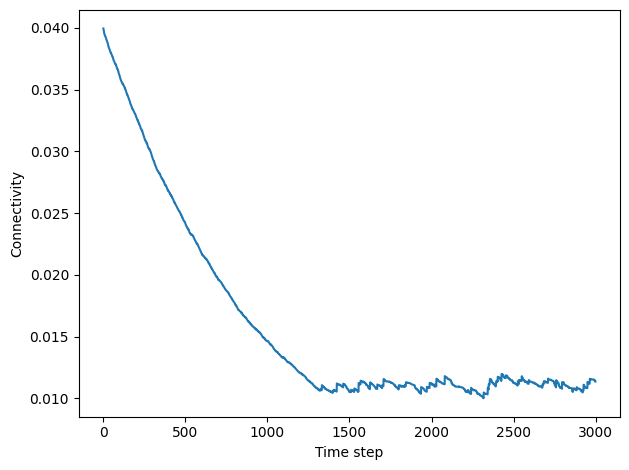

In [135]:
plt.plot(test["connectivity"])
plt.xlabel("Time step")
plt.ylabel("Connectivity")
plt.tight_layout()
plt.savefig("converge_300.png", dpi=300)

In [127]:
fire_data = test["fire_data"]

In [128]:
fire_data

array([ 64.,  67.,  65.,  64.,  68.,  75.,  68.,  69.,  74.,  72.,  65.,
        66.,  64.,  63.,  56.,  57.,  54.,  52.,  53.,  55.,  51.,  61.,
        69.,  66.,  55.,  58.,  68.,  68.,  66.,  61.,  57., 200.,   0.,
       200.,   0., 200., 300.,   0., 200.,   1.,   0., 200.,   0., 200.,
         0., 200.,   2.,   2.,   2.,   1.,   0., 200.,   1.,   1.,   0.,
       200.,   1.,   1.,   1.,   1.,   0., 200.,   1.,   0., 200.,   1.,
         1.,   6.,   4.,   4.,   4.,   8.,  15.,  17.,  29.,  26.,  34.,
        37.,  49.,  43.,  50.,  56.,  63.,  63.,  60.,  65.,  63.,  66.,
        69.,  75.,  75.,  78.,  71.,  70.,  73.,  71.,  67.,  71.,  72.,
        69.,  69.,  67.,  65.,  58.,  59.,  63.,  61.,  74.,  76.,  70.,
        68.,  68.,  66.,  70.,  64.,  65.,  59.,  62.,  66.,  69.,  66.,
        66.,  68.,  72.,  71.,  68.,  61.,  69.,  75.,  74.,  76.,  75.,
        78.,  74.,  79.,  76.,  72.,  72.,  69.,  59.,  65.,  66.,  68.,
        71.,  71.,  64.,  62.,  69.,  70.,  64.,  5

In [129]:
fire_data = np.array(fire_data)

In [97]:
fire_sum = np.sum(fire_data, axis=1)

In [130]:
fire_data.shape

(1000,)

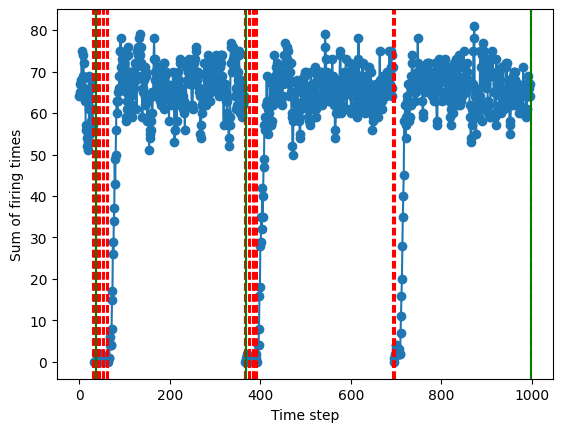

In [132]:
y = fire_data[:]
idx_inner = np.where(y == 200)[0]
idx_outer = np.where(y == 300)[0]



# replace 200 with NaN so it's not plotted
y_plot = y.astype(float)
y_plot[y_plot == 200] = np.nan
y_plot[y_plot == 300] = np.nan

plt.plot(y_plot, marker='o')

for i in idx_inner:
    plt.axvline(i, color='red', linestyle='--')

for i in idx_outer:
    plt.axvline(i, color='green', linestyle='-')

plt.xlabel("Time step")
plt.ylabel("Sum of firing times")
# plt.savefig("with_rewiring_long_cycle.png", dpi=300)
plt.show()

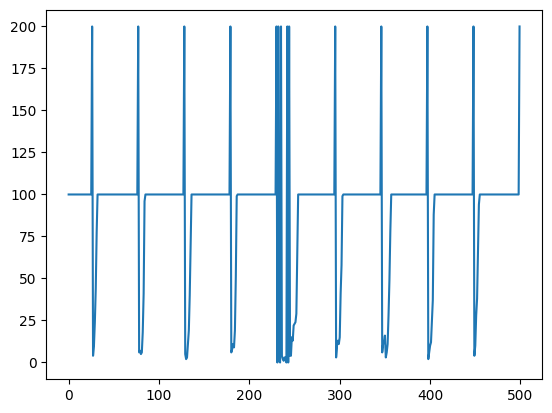

In [63]:
plt.plot(fire_sum[-500:])

In [5]:
x = np.arange(0, 4 + 0.1, 0.1)

In [6]:
x

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
       3.9, 4. ])

In [21]:
p_N100 = [t/200 for t in N100]
p_N200 = [t/200 for t in N200]

In [ ]:
from scipy.optimize import curve_fit

# sigmoid function
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k*(x - x0)))


# initial guesses
initial_guess = [max(new_test), 1, np.median(new_test)]

# fit
params, _ = curve_fit(sigmoid, x, new_test, p0=initial_guess)

L, k, x0 = params

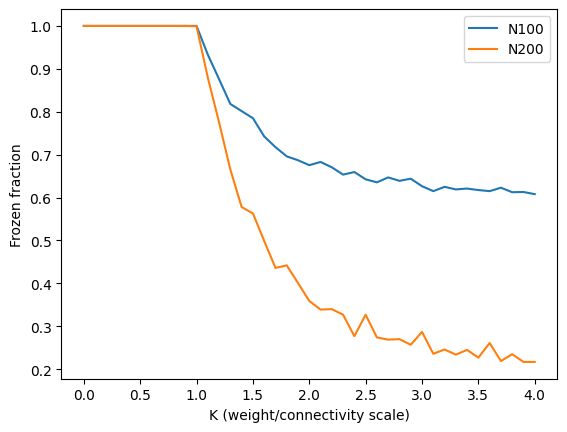

In [22]:
plt.plot(x, p_N100, label="N100")
plt.plot(x, p_N200, label="N200")
# plt.plot(x, sigmoid(x, L, k, x0))
plt.xlabel('K (weight/connectivity scale)')
plt.ylabel("Frozen fraction")
plt.legend()
# plt.savefig("frozen.png", dpi=300)

In [289]:
fire_data = test["fire_data"]

In [290]:
fire_data = np.array(fire_data)

In [291]:
fire_data.shape

(1000, 200)

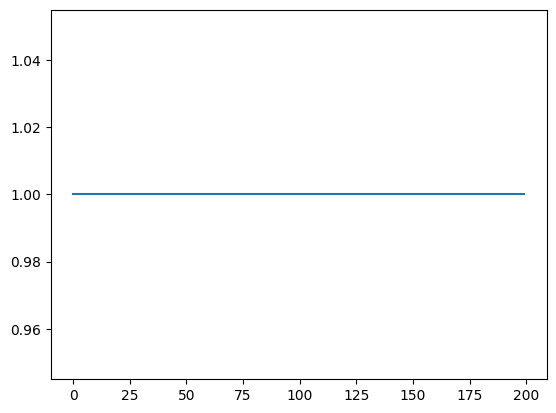

In [292]:
plt.plot(fire_data[998])

In [293]:
# last = fire_data[-3000:]
# active = (last > 0.0).any(axis=0)
# dead = ~active

In [294]:
# dead.sum().item()

In [295]:
fire_sum = np.sum(fire_data, axis=1)

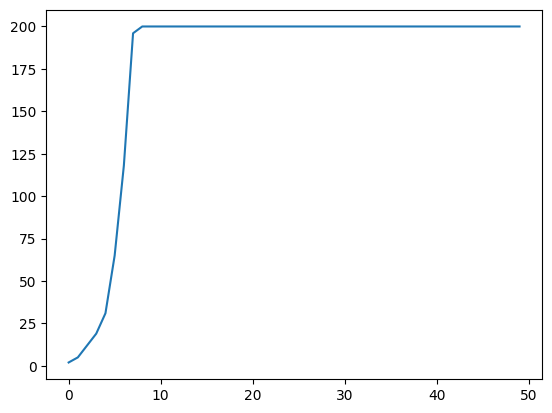

In [297]:
plt.plot(fire_sum[:50])

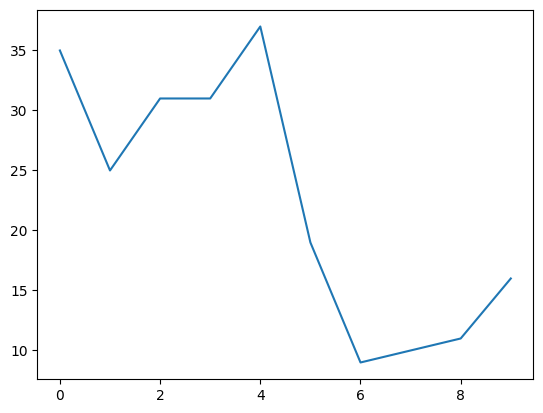

In [17]:
plt.plot(fire_sum[4000:4010])

In [6]:
N_list = [10, 20, 50, 100, 200, 400, 1000]

In [11]:
N_list[0]

10

In [13]:
len(test)

7

In [13]:
test["connectivity"]

[tensor(0.0399),
 tensor(0.0399),
 tensor(0.0398),
 tensor(0.0397),
 tensor(0.0396),
 tensor(0.0395),
 tensor(0.0394),
 tensor(0.0393),
 tensor(0.0392),
 tensor(0.0391),
 tensor(0.0391),
 tensor(0.0390),
 tensor(0.0390),
 tensor(0.0389),
 tensor(0.0388),
 tensor(0.0387),
 tensor(0.0387),
 tensor(0.0386),
 tensor(0.0385),
 tensor(0.0384),
 tensor(0.0384),
 tensor(0.0383),
 tensor(0.0382),
 tensor(0.0381),
 tensor(0.0380),
 tensor(0.0379),
 tensor(0.0379),
 tensor(0.0377),
 tensor(0.0377),
 tensor(0.0376),
 tensor(0.0375),
 tensor(0.0374),
 tensor(0.0374),
 tensor(0.0373),
 tensor(0.0372),
 tensor(0.0371),
 tensor(0.0371),
 tensor(0.0370),
 tensor(0.0369),
 tensor(0.0369),
 tensor(0.0368),
 tensor(0.0367),
 tensor(0.0367),
 tensor(0.0366),
 tensor(0.0365),
 tensor(0.0365),
 tensor(0.0364),
 tensor(0.0363),
 tensor(0.0362),
 tensor(0.0361),
 tensor(0.0361),
 tensor(0.0360),
 tensor(0.0360),
 tensor(0.0359),
 tensor(0.0358),
 tensor(0.0358),
 tensor(0.0357),
 tensor(0.0356),
 tensor(0.0356

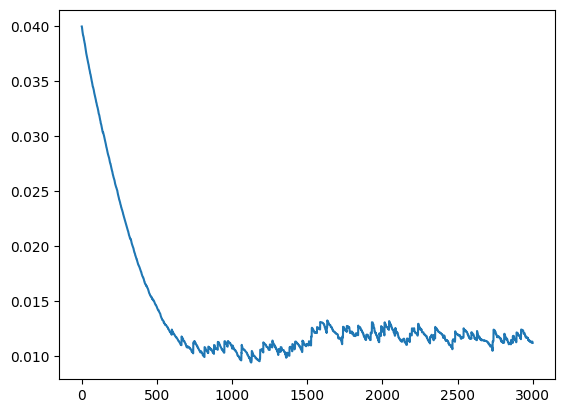

In [14]:
plt.plot(test["connectivity"])

In [ ]:
ave_connectivity = []
for i in range(len(test)):
    last = test[i]["connectivity"]
    ave_connectivity.append(sum(last)/len(last))

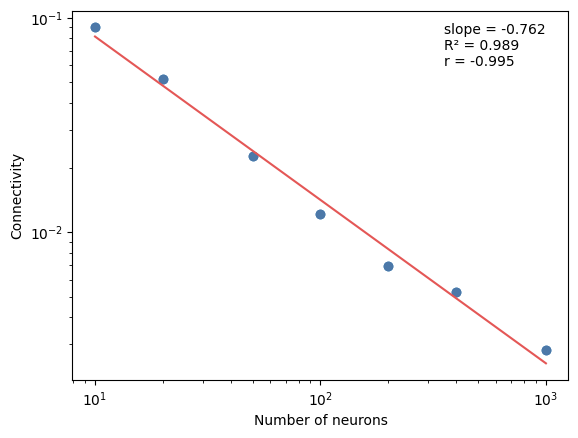

In [44]:
x = N_list
y = ave_connectivity

plt.scatter(x, y)
plt.xscale("log")
plt.yscale("log")

log_x = np.log10(x)
log_y = np.log10(y)

# regression
slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

# predicted curve
x_fit = np.linspace(min(x), max(x), 200)
y_fit = 10**intercept * x_fit**slope

# R^2
r2 = r_value**2

# plot
plt.scatter(x, y, color="#4C78A8")
plt.plot(x_fit, y_fit, color="#E45756")

plt.xscale("log")
plt.yscale("log")

# show stats on plot
plt.text(
    0.75, 0.85,
    f"slope = {slope:.3f}\nR² = {r2:.3f}\nr = {r_value:.3f}",
    transform=plt.gca().transAxes
)


plt.xlabel("Number of neurons")
plt.ylabel("Connectivity")



plt.savefig("connectivity_number.png", dpi=300)


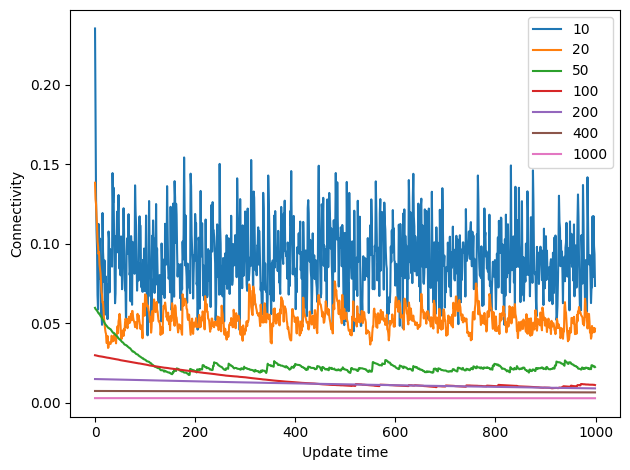

In [ ]:
for i in range(len(test)):
    plt.plot(test[i]["connectivity"][:1000], label=N_list[i])

plt.xlabel("Update time")
plt.ylabel("Connectivity")
plt.tight_layout()
plt.legend()
# plt.savefig("Ns.png", dpi=300)

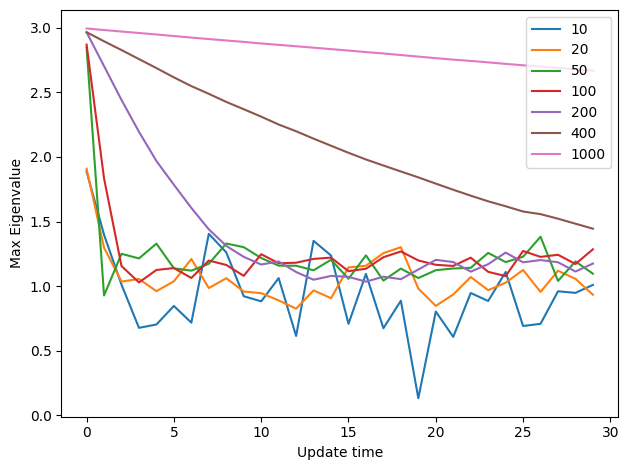

In [47]:
for i in range(len(test)):
    plt.plot(test[i]["lamb"][:], label=N_list[i])

plt.xlabel("Update time")
plt.ylabel("Max Eigenvalue")
plt.tight_layout()
plt.legend()
plt.savefig("singular.png", dpi=300)

In [6]:
test = np.array(connectivity["fire_data"])

In [7]:
test.shape

(738765, 200)

In [4]:
len(connectivity["lamb"])

1

In [9]:
x = np.linspace(0,2500,13)

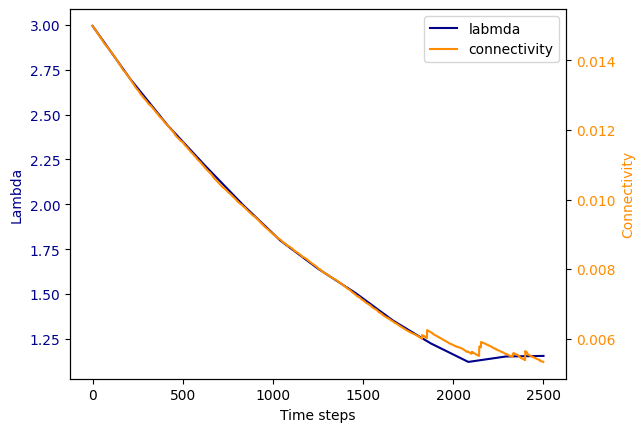

In [10]:
fig, ax1 = plt.subplots()

line1, = ax1.plot(x, connectivity["lamb"], label="labmda", color="darkblue")
ax1.set_xlabel("Time steps")
ax1.set_ylabel("Lambda", color="darkblue")
ax1.tick_params(axis="y", labelcolor="darkblue")

ax2 = ax1.twinx()
line2, = ax2.plot(connectivity["connectivity"], label="connectivity", color="darkorange")
ax2.set_ylabel("Connectivity", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

# fig.savefig("connect_lambda.png", dpi=300)

In [152]:
connectivity = np.array(connectivity)

In [153]:
connectivity.shape

(729152, 200)

In [162]:
test = connectivity[610000:611000]

In [11]:
test_sum = test.sum(axis=0)

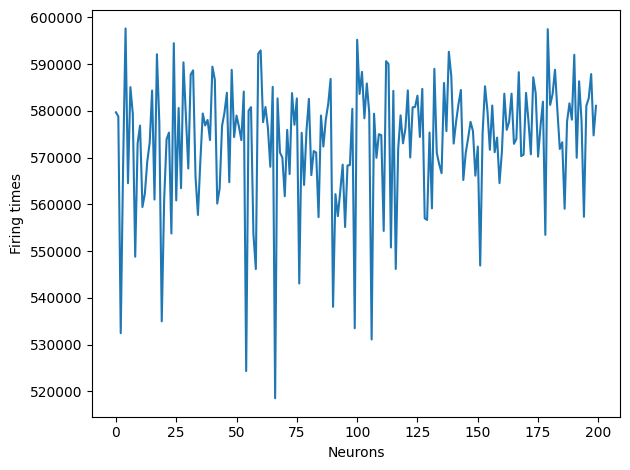

In [12]:
plt.plot(test_sum)
plt.xlabel('Neurons')
plt.ylabel('Firing times')
plt.tight_layout()
# plt.savefig("frozen.png", dpi=300)

In [105]:
small_fire_data = connectivity[:1000]

In [95]:
sum_fire = connectivity.sum(axis=-1)

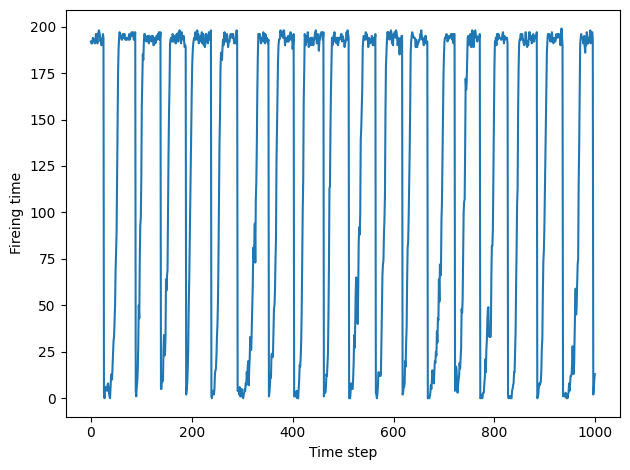

In [149]:
plt.plot(sum_fire[610000:611000])
plt.xlabel('Time step')
plt.ylabel('Fireing time')
plt.tight_layout()
plt.savefig("fire_patterns_middle.png", dpi=300)

In [106]:
small_fire_data = np.array(small_fire_data)

In [107]:
with open(f'fire_data.pkl', 'wb') as f:
    pickle.dump(small_fire_data, f)

In [85]:
len(connectivity)

729152

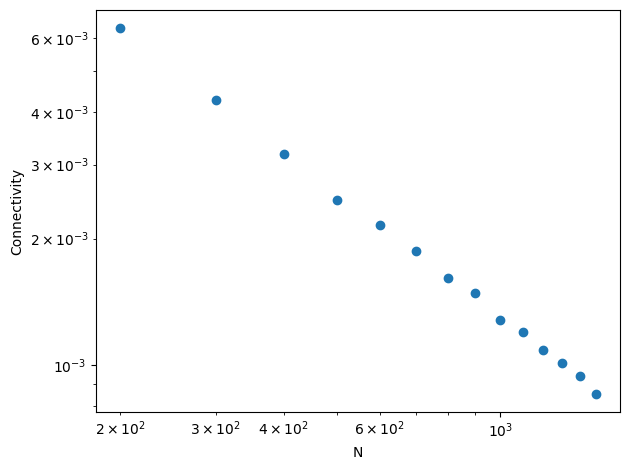

In [144]:
plt.scatter(nums, connectivity["connectivity"])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Connectivity')
plt.tight_layout()
plt.savefig("without_N_Connect.png", dpi=300)

In [141]:
np.log(connectivity["lambdass"][0][-1])

0.21127173504869035

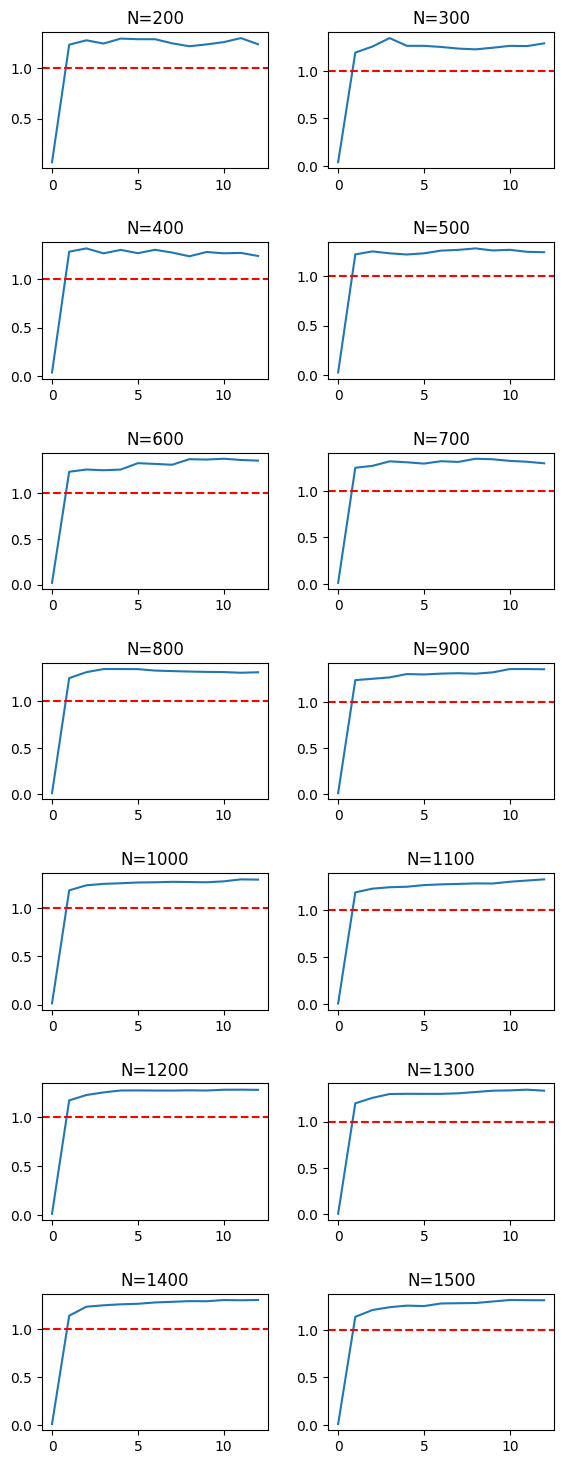

In [142]:
fig, axes = plt.subplots(7,2, figsize=(6, 15))

for i, ax in enumerate(axes.flatten()[:14]):
    ax.plot(connectivity["lambdass"][i])
    ax.set_title(f"N={nums[i]}")
    # ax.set_ylim(0,5)
    ax.axhline(y=1, linestyle="--", color="red")

plt.tight_layout(pad=2.0)
plt.savefig("without_N_Lambda.png", dpi=300)

In [49]:
len(connectivity["lambdass"])

14

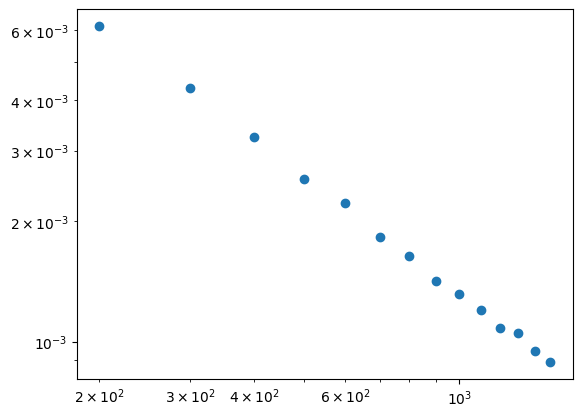

In [38]:
plt.scatter(nums, connectivity)
plt.xscale('log')
plt.yscale('log')

In [18]:
connectivity = np.array(connectivity)

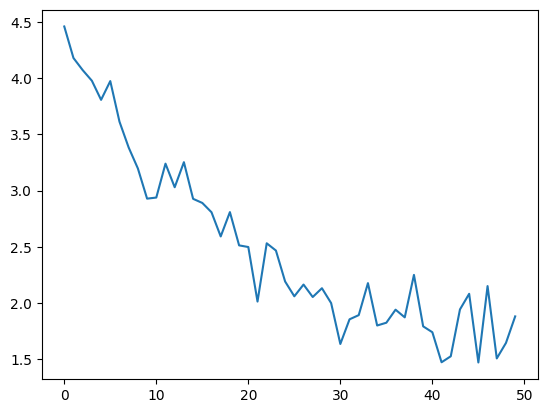

In [31]:
plt.plot(connectivity["train_losses"])

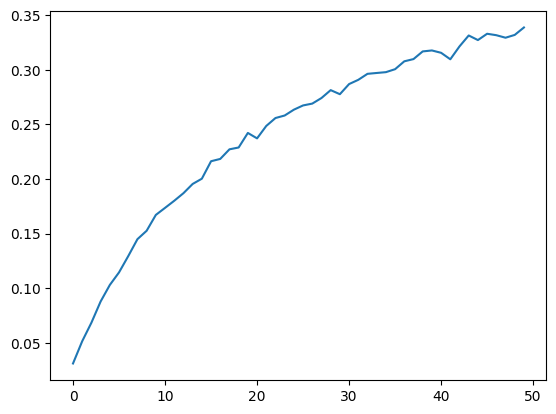

In [32]:
plt.plot(connectivity["val_accuracies"])

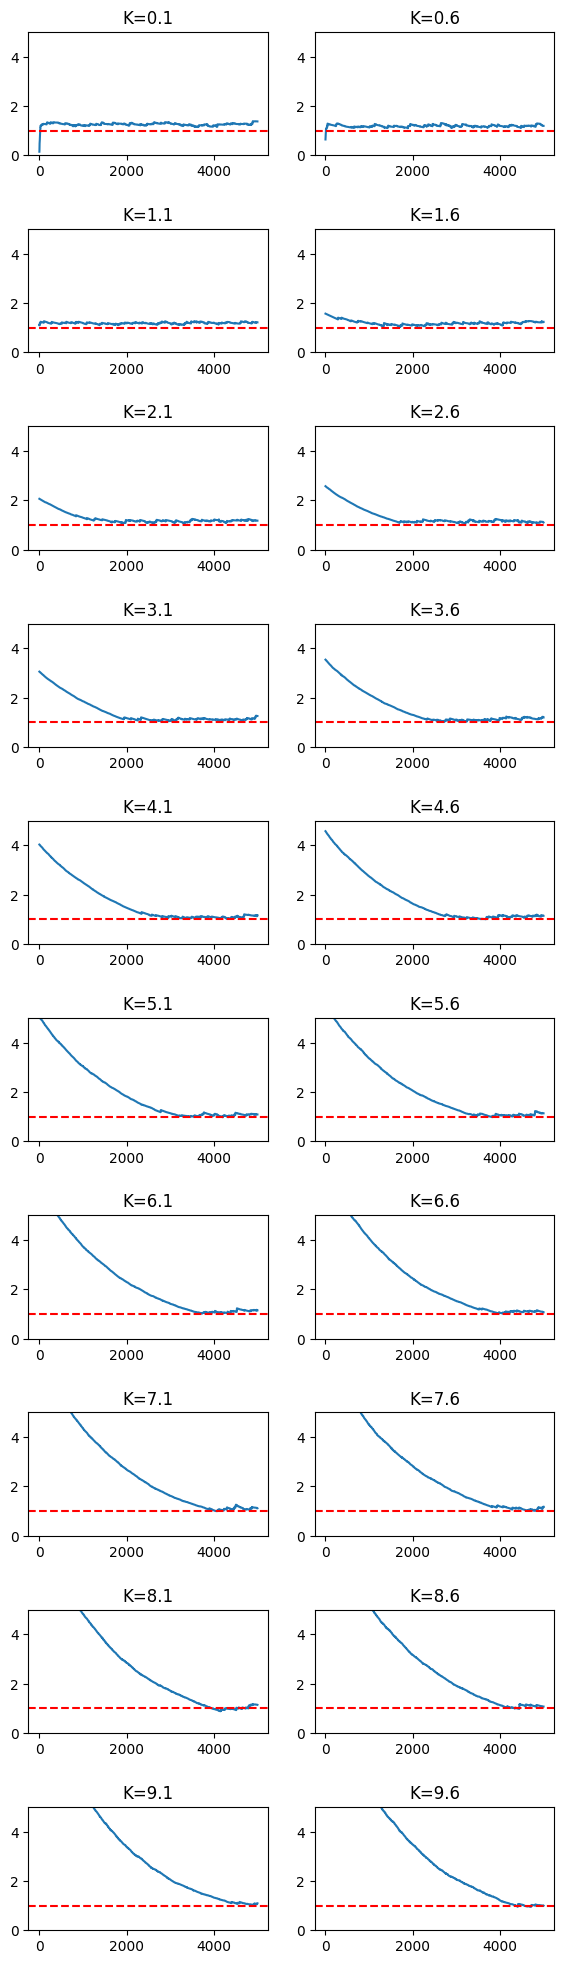

In [32]:
fig, axes = plt.subplots(10,2, figsize=(6, 20))
x = np.arange(0.1, 10, 0.5)

for i, ax in enumerate(axes.flatten()):
    ax.plot(connectivity[i])
    ax.set_title(f"K={x[i]}")
    ax.set_ylim(0,5)
    ax.axhline(y=1, linestyle="--", color="red")

plt.tight_layout(pad=2.0)
plt.savefig("ks.png", dpi=300)

In [9]:
# nums = np.arange(200, 1300, 100)
nums = np.arange(200, 1600, 100)

In [7]:
nums

array([ 200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100, 1200])

In [3]:
connectivity

[tensor(0.0072),
 tensor(0.0096),
 tensor(0.0091),
 tensor(0.0082),
 tensor(0.0073),
 tensor(0.0064),
 tensor(0.0058),
 tensor(0.0052),
 tensor(0.0048),
 tensor(0.0044),
 tensor(0.0040)]

In [16]:
a, b = np.polyfit(nums[2:], connectivity[2:], 1)

In [17]:
y_pred = a*nums[2:] + b

In [18]:
a

-5.1858683582395295e-06

In [21]:
log_nums = np.log(nums[1:])
log_c = np.log(connectivity[1:])

In [26]:
pred = log_nums*result.slope + result.intercept

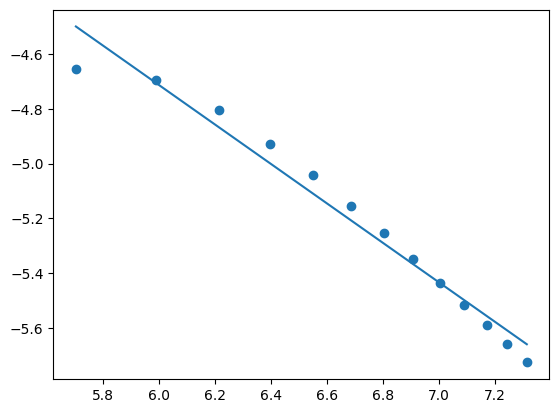

In [28]:
plt.scatter(log_nums, log_c)
plt.plot(log_nums, pred)

In [24]:
from scipy.stats import linregress

result = linregress(log_nums, log_c)

In [25]:
result

LinregressResult(slope=-0.7205522587999688, intercept=-0.3899918096762187, rvalue=-0.984413357555503, pvalue=1.1864910214402458e-09, stderr=0.038813606682343404, intercept_stderr=0.2606471561605881)

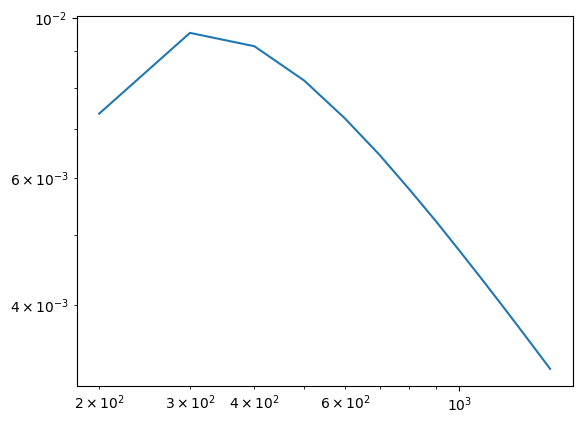

In [20]:
plt.plot(nums[:], connectivity[:])
# plt.plot(nums[2:], y_pred)
plt.xscale('log')
plt.yscale('log')
